In [ ]:
import numpy as np
import warnings
warnings.filterwarnings("ignore", message=".*The 'nopython' keyword.*")
import pandas as pd
import scanpy as sc
import os
import matplotlib.pyplot as plt
import seaborn as sns
seed = 10
np.random.seed(seed)
sc.settings.verbosity = 3
import scrublet as scr
sc.settings.set_figure_params(dpi=80, facecolor='white')

## Read .matrix

In [ ]:
# WT Recipient Day1
DMD_sample1 = sc.read_10x_mtx('./humanDMD/fastq/DMD1_count/outs/filtered_feature_bc_matrix/', var_names='gene_symbols',cache=True)
DMD_sample2 = sc.read_10x_mtx('./humanDMD/fastq/DMD2_count/outs/filtered_feature_bc_matrix/', var_names='gene_symbols',cache=True)
DMD_sample3 = sc.read_10x_mtx('./humanDMD/fastq/DMD3_count/outs/filtered_feature_bc_matrix/', var_names='gene_symbols',cache=True)
Healthy_sample1 = sc.read_10x_mtx('./humanDMD/fastq/Healthy1_count/outs/filtered_feature_bc_matrix/', var_names='gene_symbols',cache=True)        
Healthy_sample2 = sc.read_10x_mtx('./humanDMD/fastq/Healthy2_count/outs/filtered_feature_bc_matrix/', var_names='gene_symbols',cache=True)         

... reading from cache file cache/mnt-md0-jiahui-humanDMD-fastq-DMD1_count-outs-filtered_feature_bc_matrix-matrix.h5ad


... reading from cache file cache/mnt-md0-jiahui-humanDMD-fastq-DMD2_count-outs-filtered_feature_bc_matrix-matrix.h5ad
... reading from cache file cache/mnt-md0-jiahui-humanDMD-fastq-DMD3_count-outs-filtered_feature_bc_matrix-matrix.h5ad
... reading from cache file cache/mnt-md0-jiahui-humanDMD-fastq-Healthy1_count-outs-filtered_feature_bc_matrix-matrix.h5ad
... reading from cache file cache/mnt-md0-jiahui-humanDMD-fastq-Healthy2_count-outs-filtered_feature_bc_matrix-matrix.h5ad


In [205]:
for i,a in enumerate([DMD_sample1,DMD_sample2,DMD_sample3,Healthy_sample1,Healthy_sample2]):
    a.obs['dataset']=str(i)

In [206]:
adata_merge = DMD_sample1.concatenate(DMD_sample2,DMD_sample3,Healthy_sample1,Healthy_sample2, batch_key='sample')

/tmp/ipykernel_606254/199008384.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merge = DMD_sample1.concatenate(DMD_sample2,DMD_sample3,Healthy_sample1,Healthy_sample2, batch_key='sample')


In [ ]:
sample_mapping = {'0': 'DMD', '1': 'DMD', '2': 'DMD', '3': 'healthy','4': 'healthy'}
samples = adata_merge.obs['sample'].replace(sample_mapping)
valid_genes = ['IFNAR1', 'IFNAR2', 'IFNB1']
gene_expression = np.expm1(adata_merge[:, valid_genes].X.toarray())

df = pd.DataFrame(gene_expression, columns=valid_genes, index=samples)
mean_expression = df.groupby(df.index).mean()
mean_expression


## Pre-processing

In [209]:
adata_merge.var_names_make_unique()

normalizing counts per cell
    finished (0:00:00)


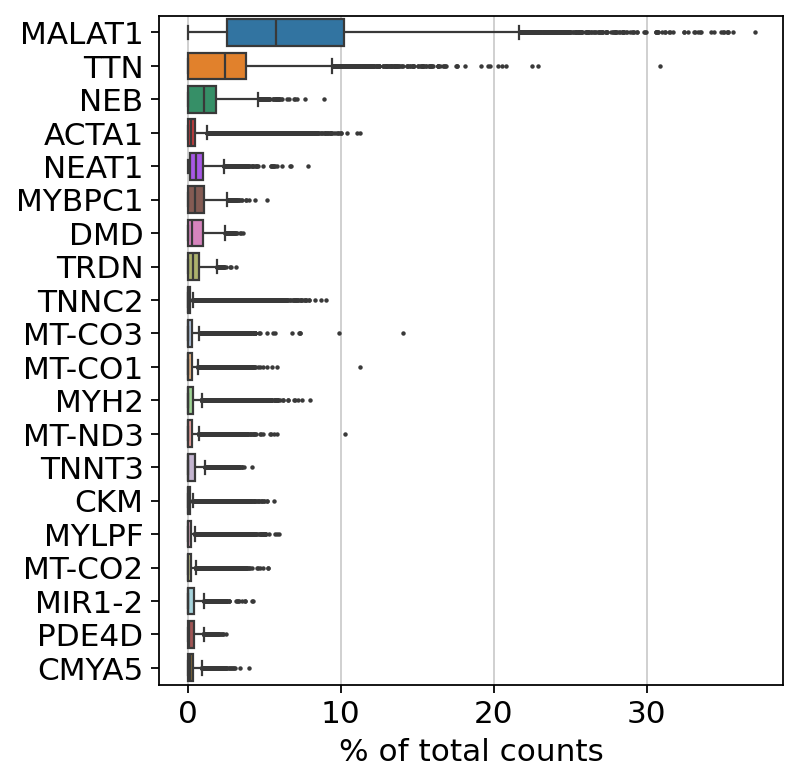

In [210]:
# Show those genes that yield the highest fraction of counts in each single cell, across all cells.
sc.pl.highest_expr_genes(adata_merge, n_top=20, )

In [211]:
# Basic filtering
sc.pp.filter_cells(adata_merge, min_genes=200)
sc.pp.filter_genes(adata_merge, min_cells=3)
adata_merge.shape

filtered out 254 cells that have less than 200 genes expressed
filtered out 9810 genes that are detected in less than 3 cells


(8529, 22928)

In [212]:
adata_merge.var['mt'] = adata_merge.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata_merge, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

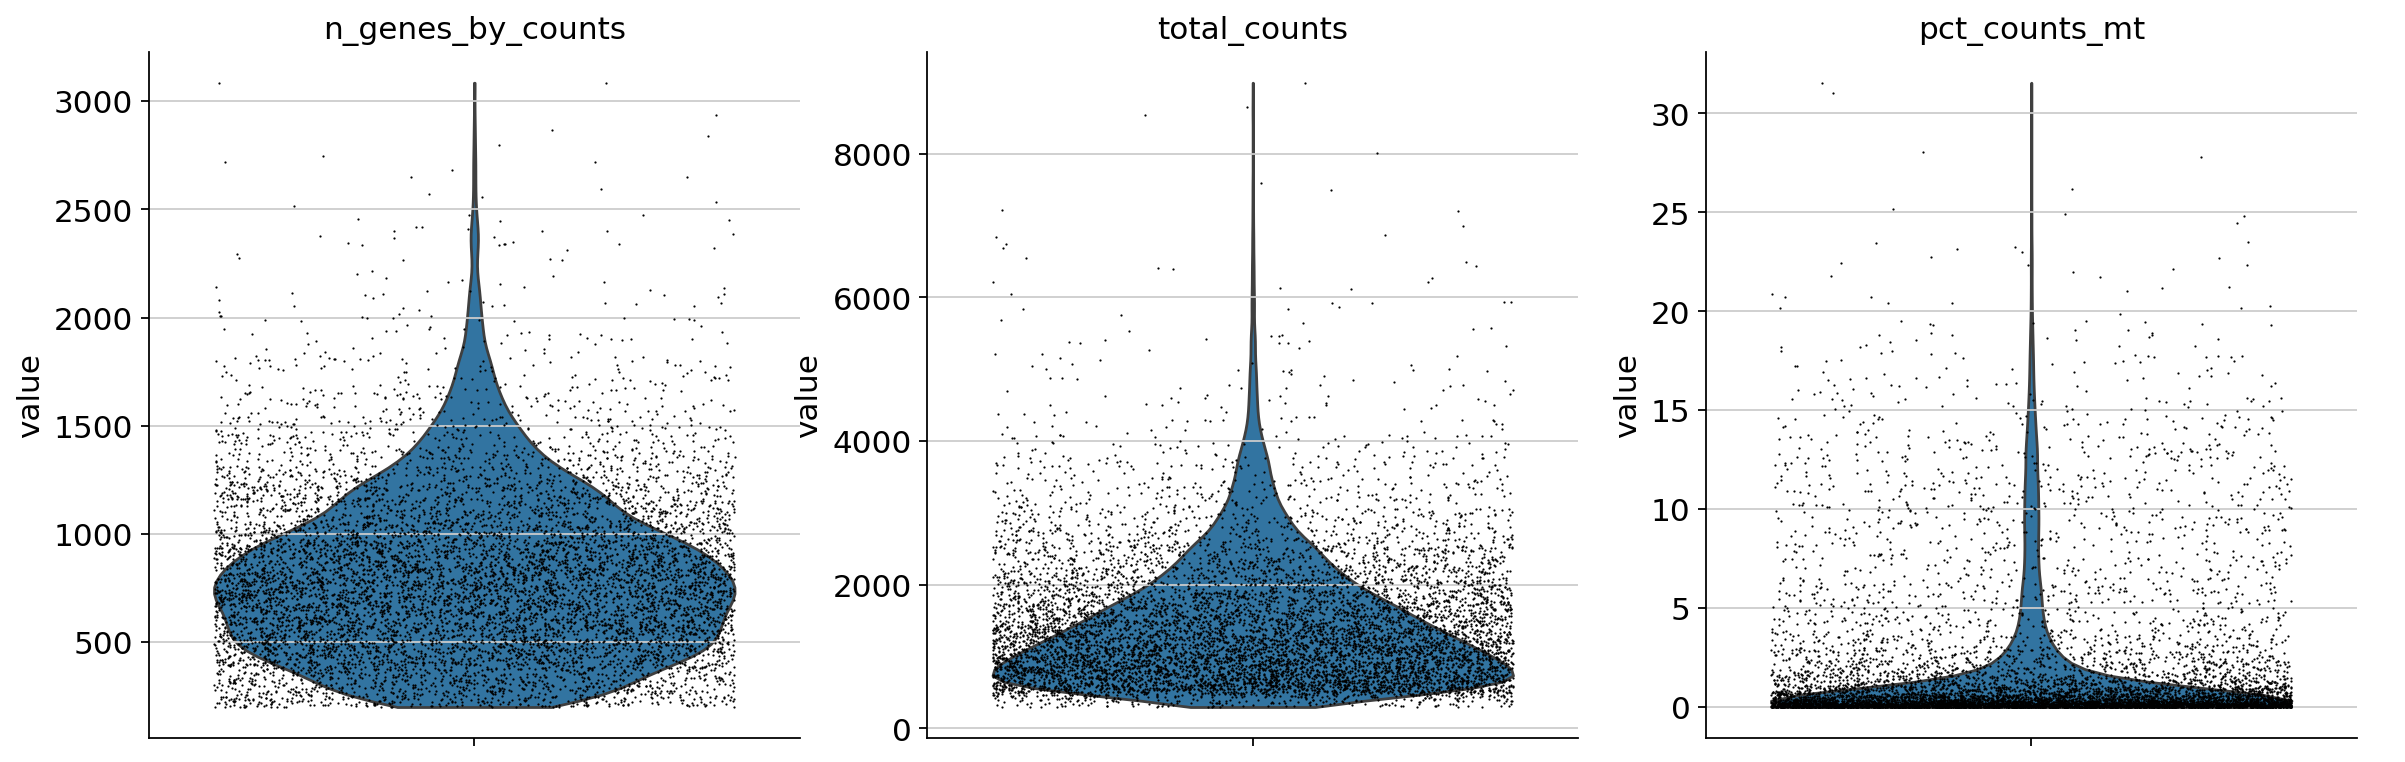

In [213]:
sc.pl.violin(adata_merge, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)

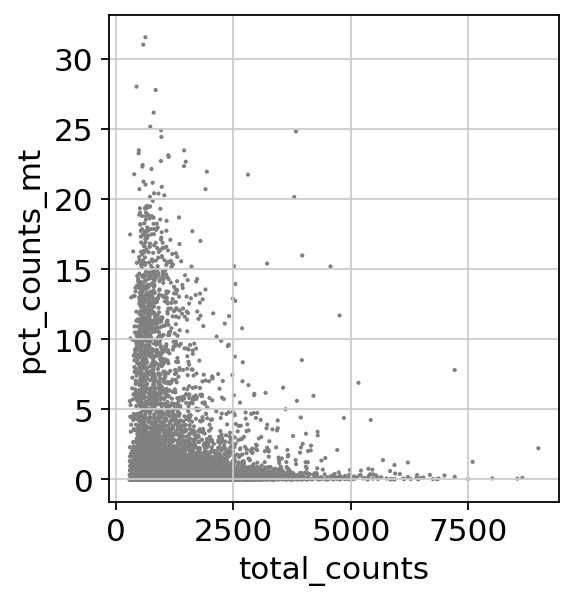

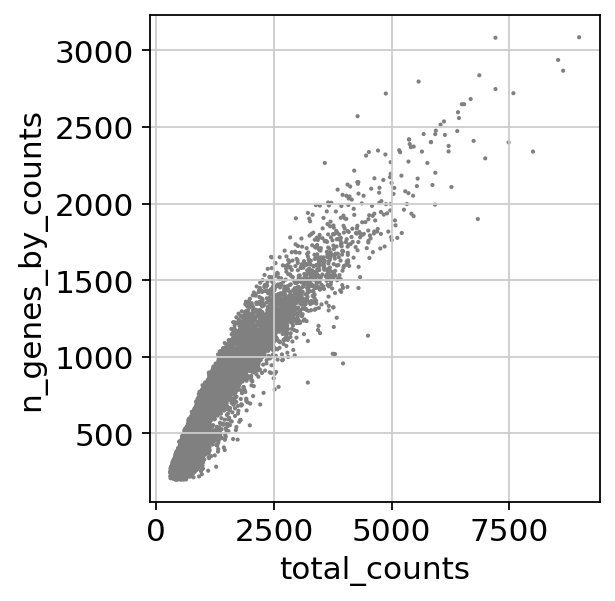

In [214]:
sc.pl.scatter(adata_merge, x='total_counts', y='pct_counts_mt')
sc.pl.scatter(adata_merge, x='total_counts', y='n_genes_by_counts')

In [215]:
adata_merge = adata_merge[adata_merge.obs.n_genes_by_counts < 3000, :]
adata_merge = adata_merge[adata_merge.obs.pct_counts_mt < 10, :]
adata_merge

View of AnnData object with n_obs × n_vars = 7978 × 22928
    obs: 'dataset', 'sample', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

In [216]:
adata_merge = adata_merge[adata_merge[:,adata_merge.var.index=='PTPRC'].X.todense() > 0,:]
adata_merge.shape

(278, 22928)

In [217]:
sc.pp.normalize_total(adata_merge, target_sum=1e4)

normalizing counts per cell
    finished (0:00:00)


/mnt/md0/jiahui/anaconda3/envs/sra_env/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [ ]:
adata_merge.write("./humanDMD_normalized.h5ad")

In [170]:
sc.pp.log1p(adata_merge)

In [171]:
sc.pp.highly_variable_genes(adata_merge, min_mean=0.0125, max_mean=3, min_disp=0.5)

extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


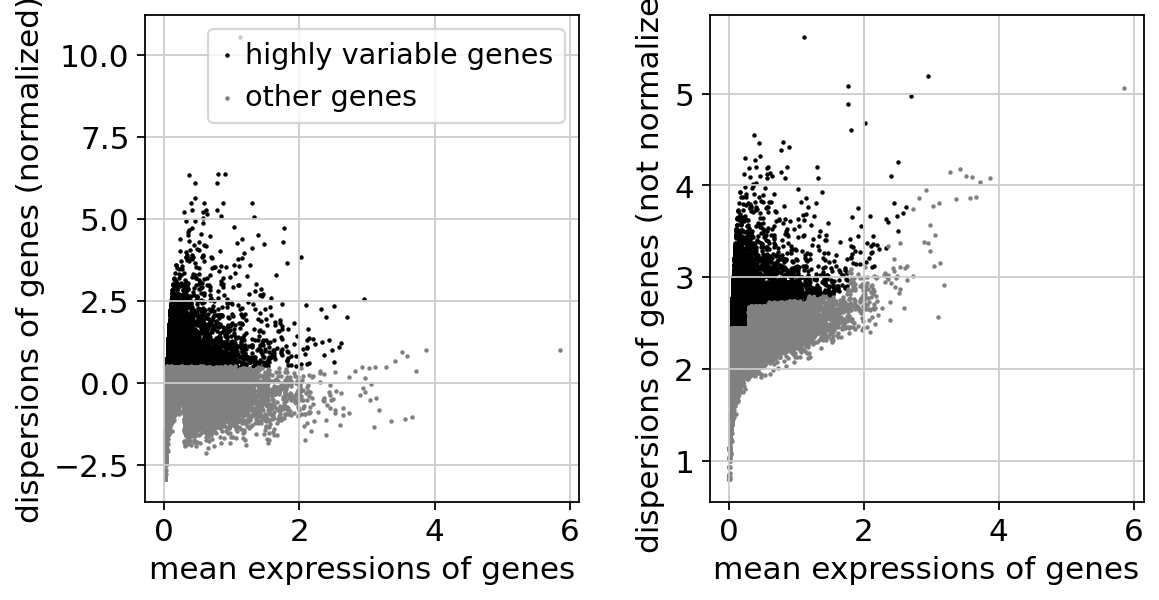

In [172]:
sc.pl.highly_variable_genes(adata_merge)

In [173]:
adata_merge.raw = adata_merge

In [174]:
adata_merge = adata_merge[:, adata_merge.var.highly_variable]
adata_merge.shape

(278, 4313)

In [175]:
sc.pp.regress_out(adata_merge, ['total_counts', 'pct_counts_mt'])

regressing out ['total_counts', 'pct_counts_mt']
    sparse input is densified and may lead to high memory use
    finished (0:00:00)


/mnt/md0/jiahui/anaconda3/envs/sra_env/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:729: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [176]:
sc.pp.scale(adata_merge, max_value=10)

In [177]:
sc.tl.pca(adata_merge, svd_solver='arpack')

computing PCA
    with n_comps=50
    finished (0:00:04)


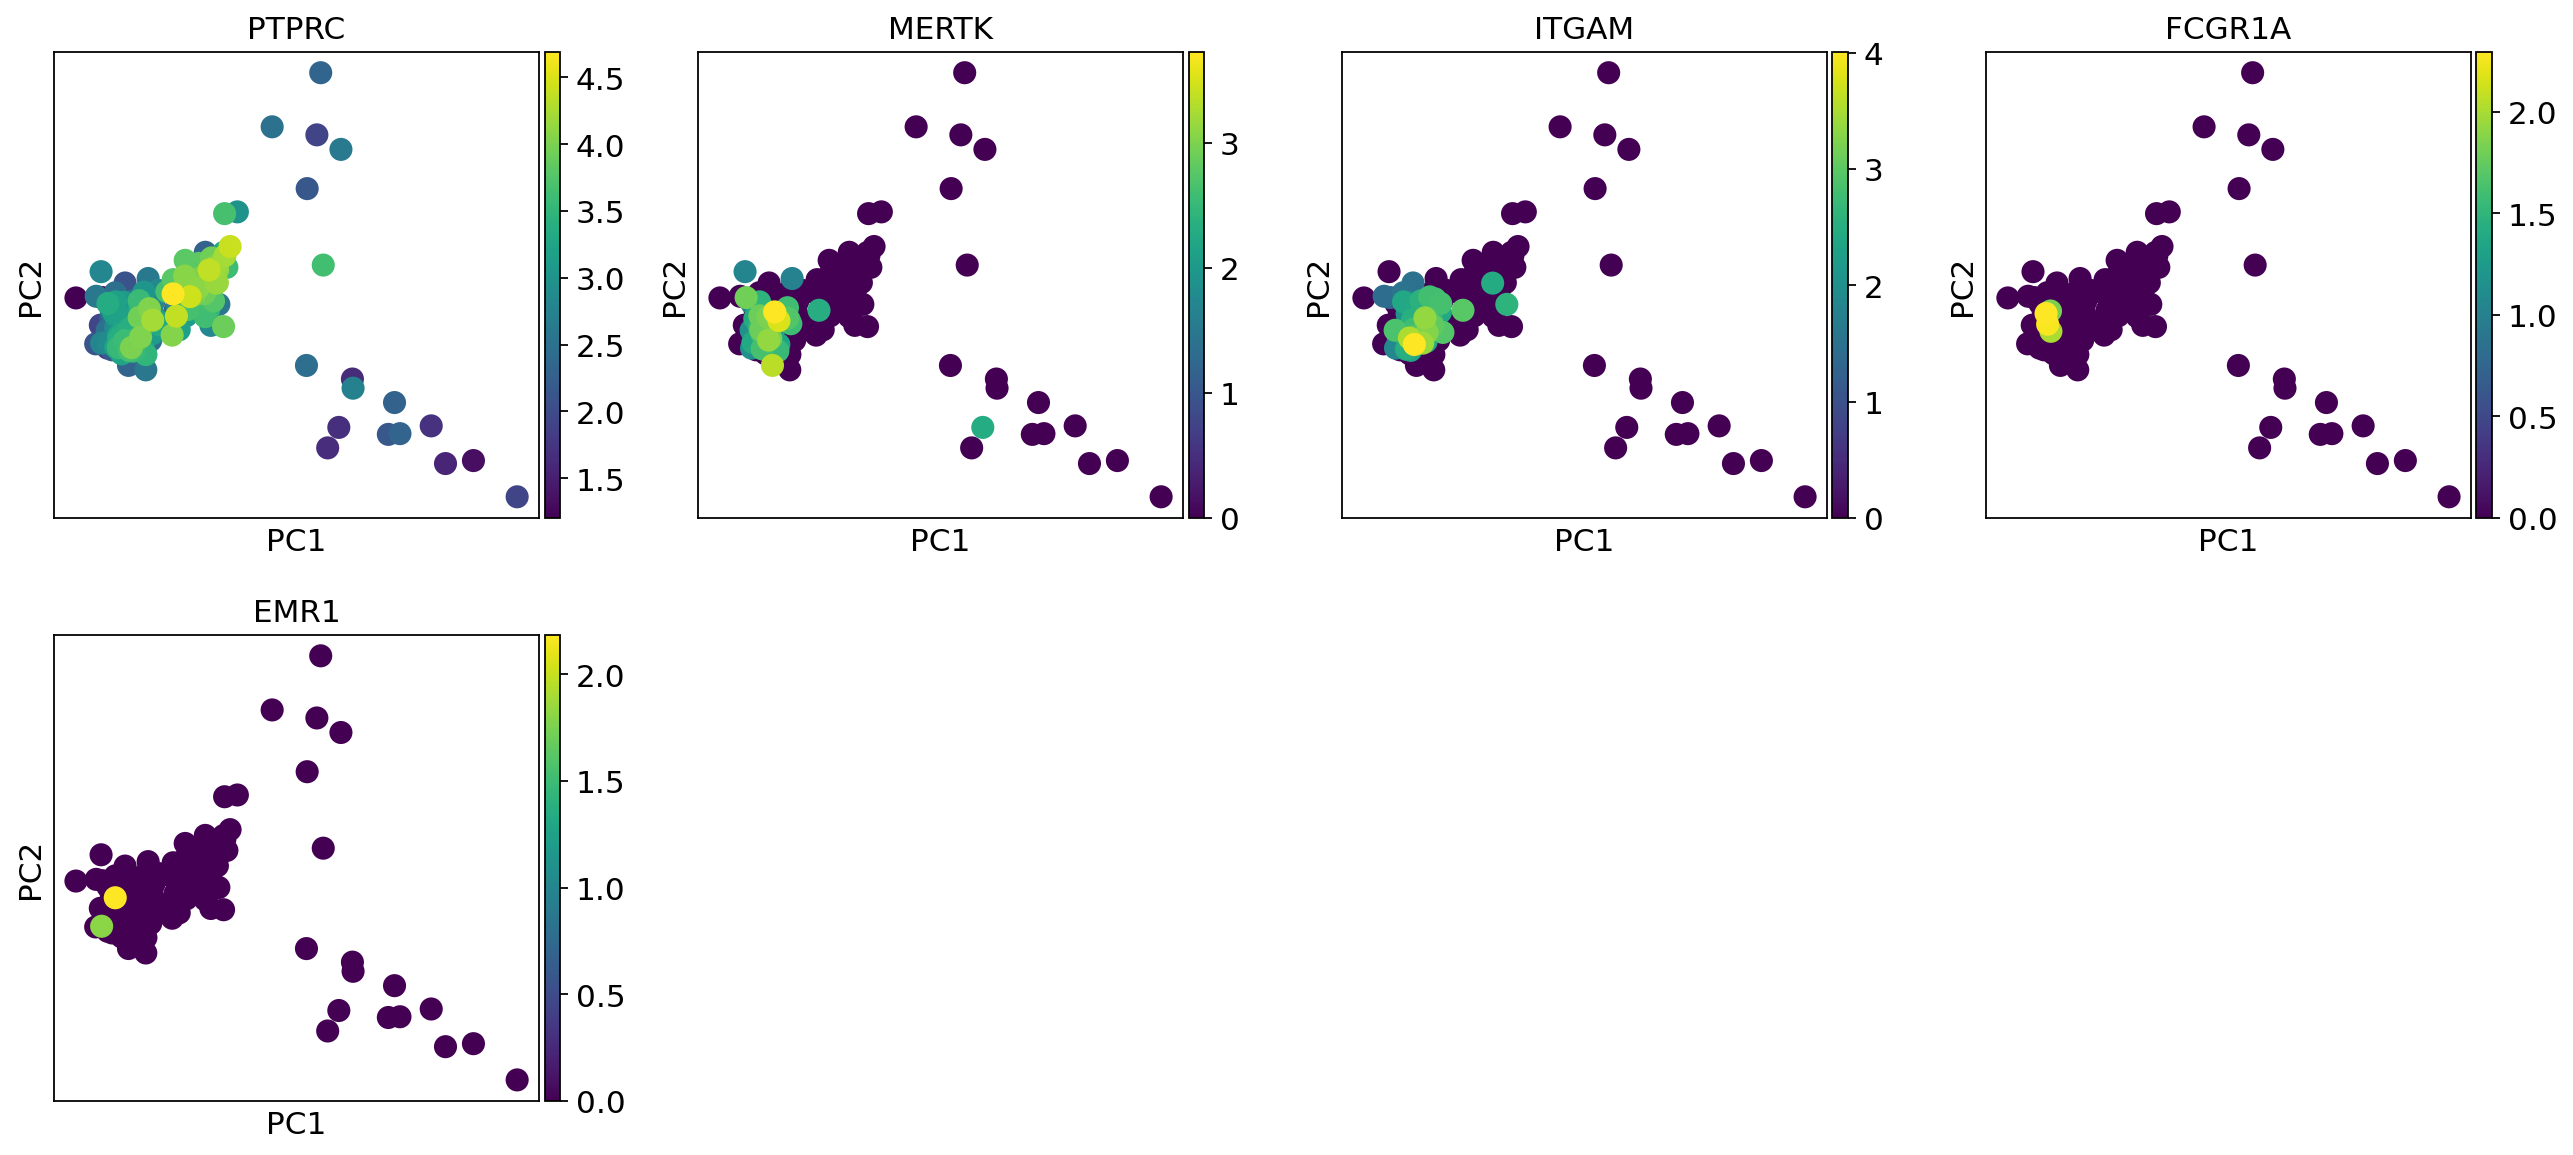

In [178]:
sc.pl.pca(adata_merge, color=['PTPRC', 'MERTK',"ITGAM","FCGR1A","EMR1"])

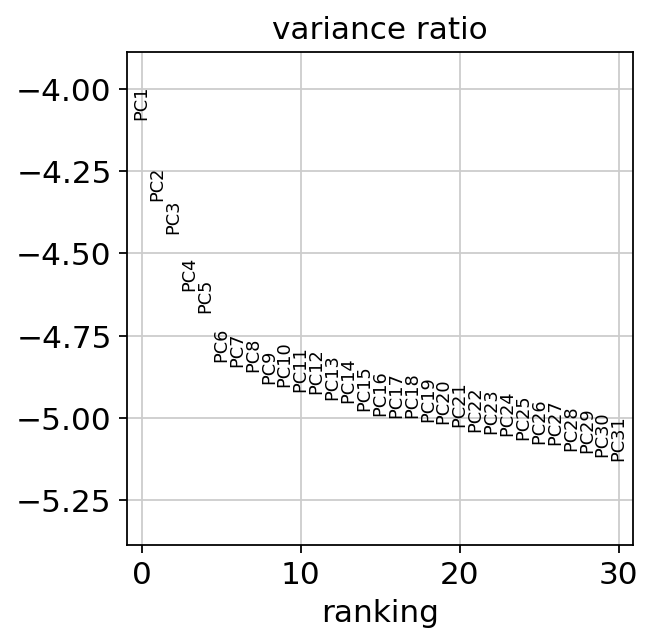

In [179]:
sc.pl.pca_variance_ratio(adata_merge, log=True)

2025-10-20 15:39:56,011 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-10-20 15:39:56,866 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-10-20 15:39:56,871 - harmonypy - INFO - Iteration 1 of 10
2025-10-20 15:39:56,904 - harmonypy - INFO - Iteration 2 of 10
2025-10-20 15:39:56,925 - harmonypy - INFO - Iteration 3 of 10
2025-10-20 15:39:56,939 - harmonypy - INFO - Iteration 4 of 10
2025-10-20 15:39:56,955 - harmonypy - INFO - Iteration 5 of 10
2025-10-20 15:39:56,974 - harmonypy - INFO - Iteration 6 of 10
2025-10-20 15:39:56,992 - harmonypy - INFO - Iteration 7 of 10
2025-10-20 15:39:57,007 - harmonypy - INFO - Iteration 8 of 10
2025-10-20 15:39:57,022 - harmonypy - INFO - Iteration 9 of 10
2025-10-20 15:39:57,038 - harmonypy - INFO - Converged after 9 iterations


computing neighbors
    using 'X_pca' with n_pcs = 40
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:00)


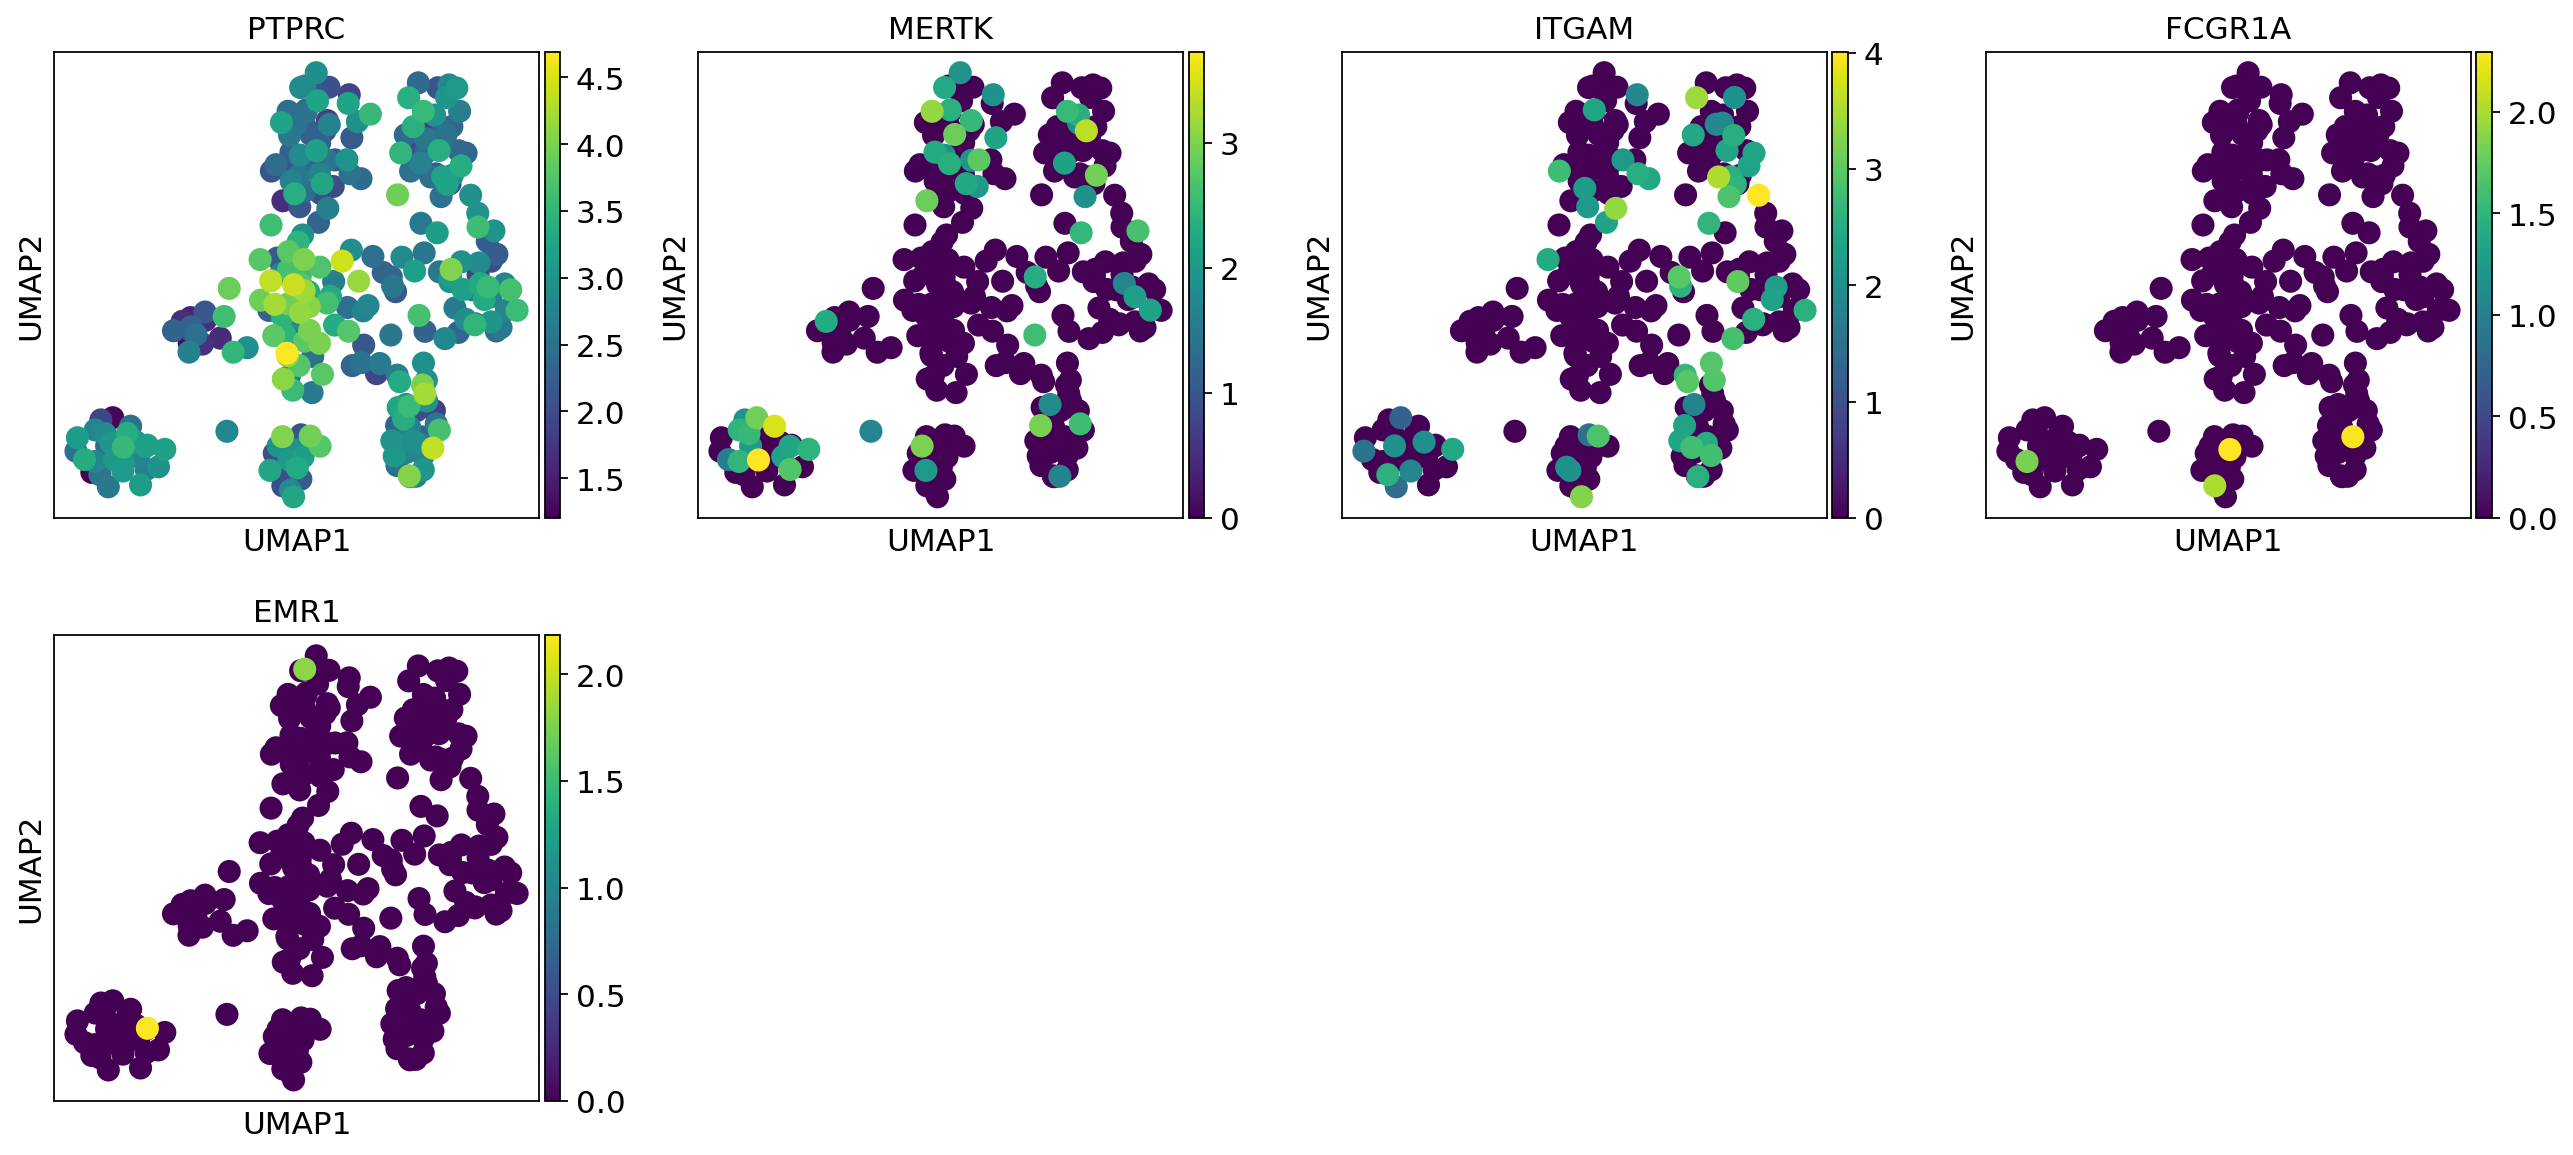

In [180]:
adata_H = adata_merge.copy()
sc.external.pp.harmony_integrate(adata_H,key='dataset',adjusted_basis='X_pca')
sc.pp.neighbors(adata_H, n_neighbors=10, n_pcs=40) #Compute the neighborhood graph of cells using the PCA representation
sc.tl.umap(adata_H) #Embed the neighborhood graph using UMAP.
sc.pl.umap(adata_H, color=['PTPRC', 'MERTK',"ITGAM","FCGR1A","EMR1"]) #Plot the UMAP and color by the genes of interest.

### check resolution 

In [182]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_samples, silhouette_score
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_samples, silhouette_score
from matplotlib import cm

running Leiden clustering
    finished: found 8 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


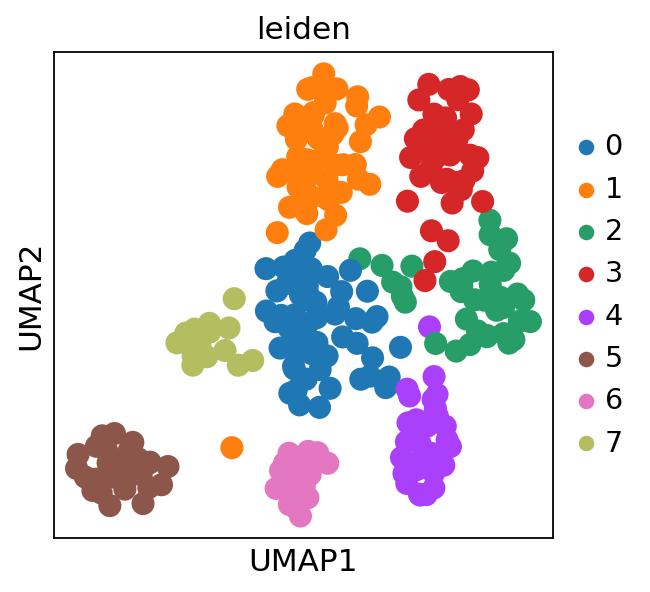

In [183]:
sc.tl.leiden(adata_H, resolution = 0.6)
sc.pl.umap(adata_H, color=['leiden'], use_raw=False) # resolution

In [184]:
replacement_dict = {'0': 'DMD', '1': 'DMD', '2': 'DMD', '3': 'Healthy','4': 'Healthy'}
replacement_dict

{'0': 'DMD', '1': 'DMD', '2': 'DMD', '3': 'Healthy', '4': 'Healthy'}

In [185]:
sc.set_figure_params(figsize=(4, 4))

/tmp/ipykernel_606254/2164250766.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_H.obs['WT_sum_cat'] = adata_H.obs['sample'].replace(replacement_dict)


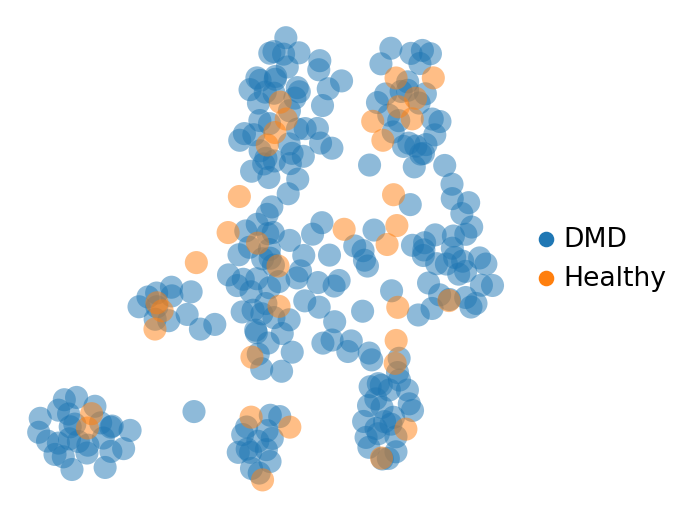

In [186]:
adata_H.obs['WT_sum_cat'] = adata_H.obs['sample'].replace(replacement_dict)
sc.pl.umap(adata_H,  color='WT_sum_cat', alpha=0.5, title='', frameon=False,legend_fontsize = 12,legend_fontweight = 'semibold' )

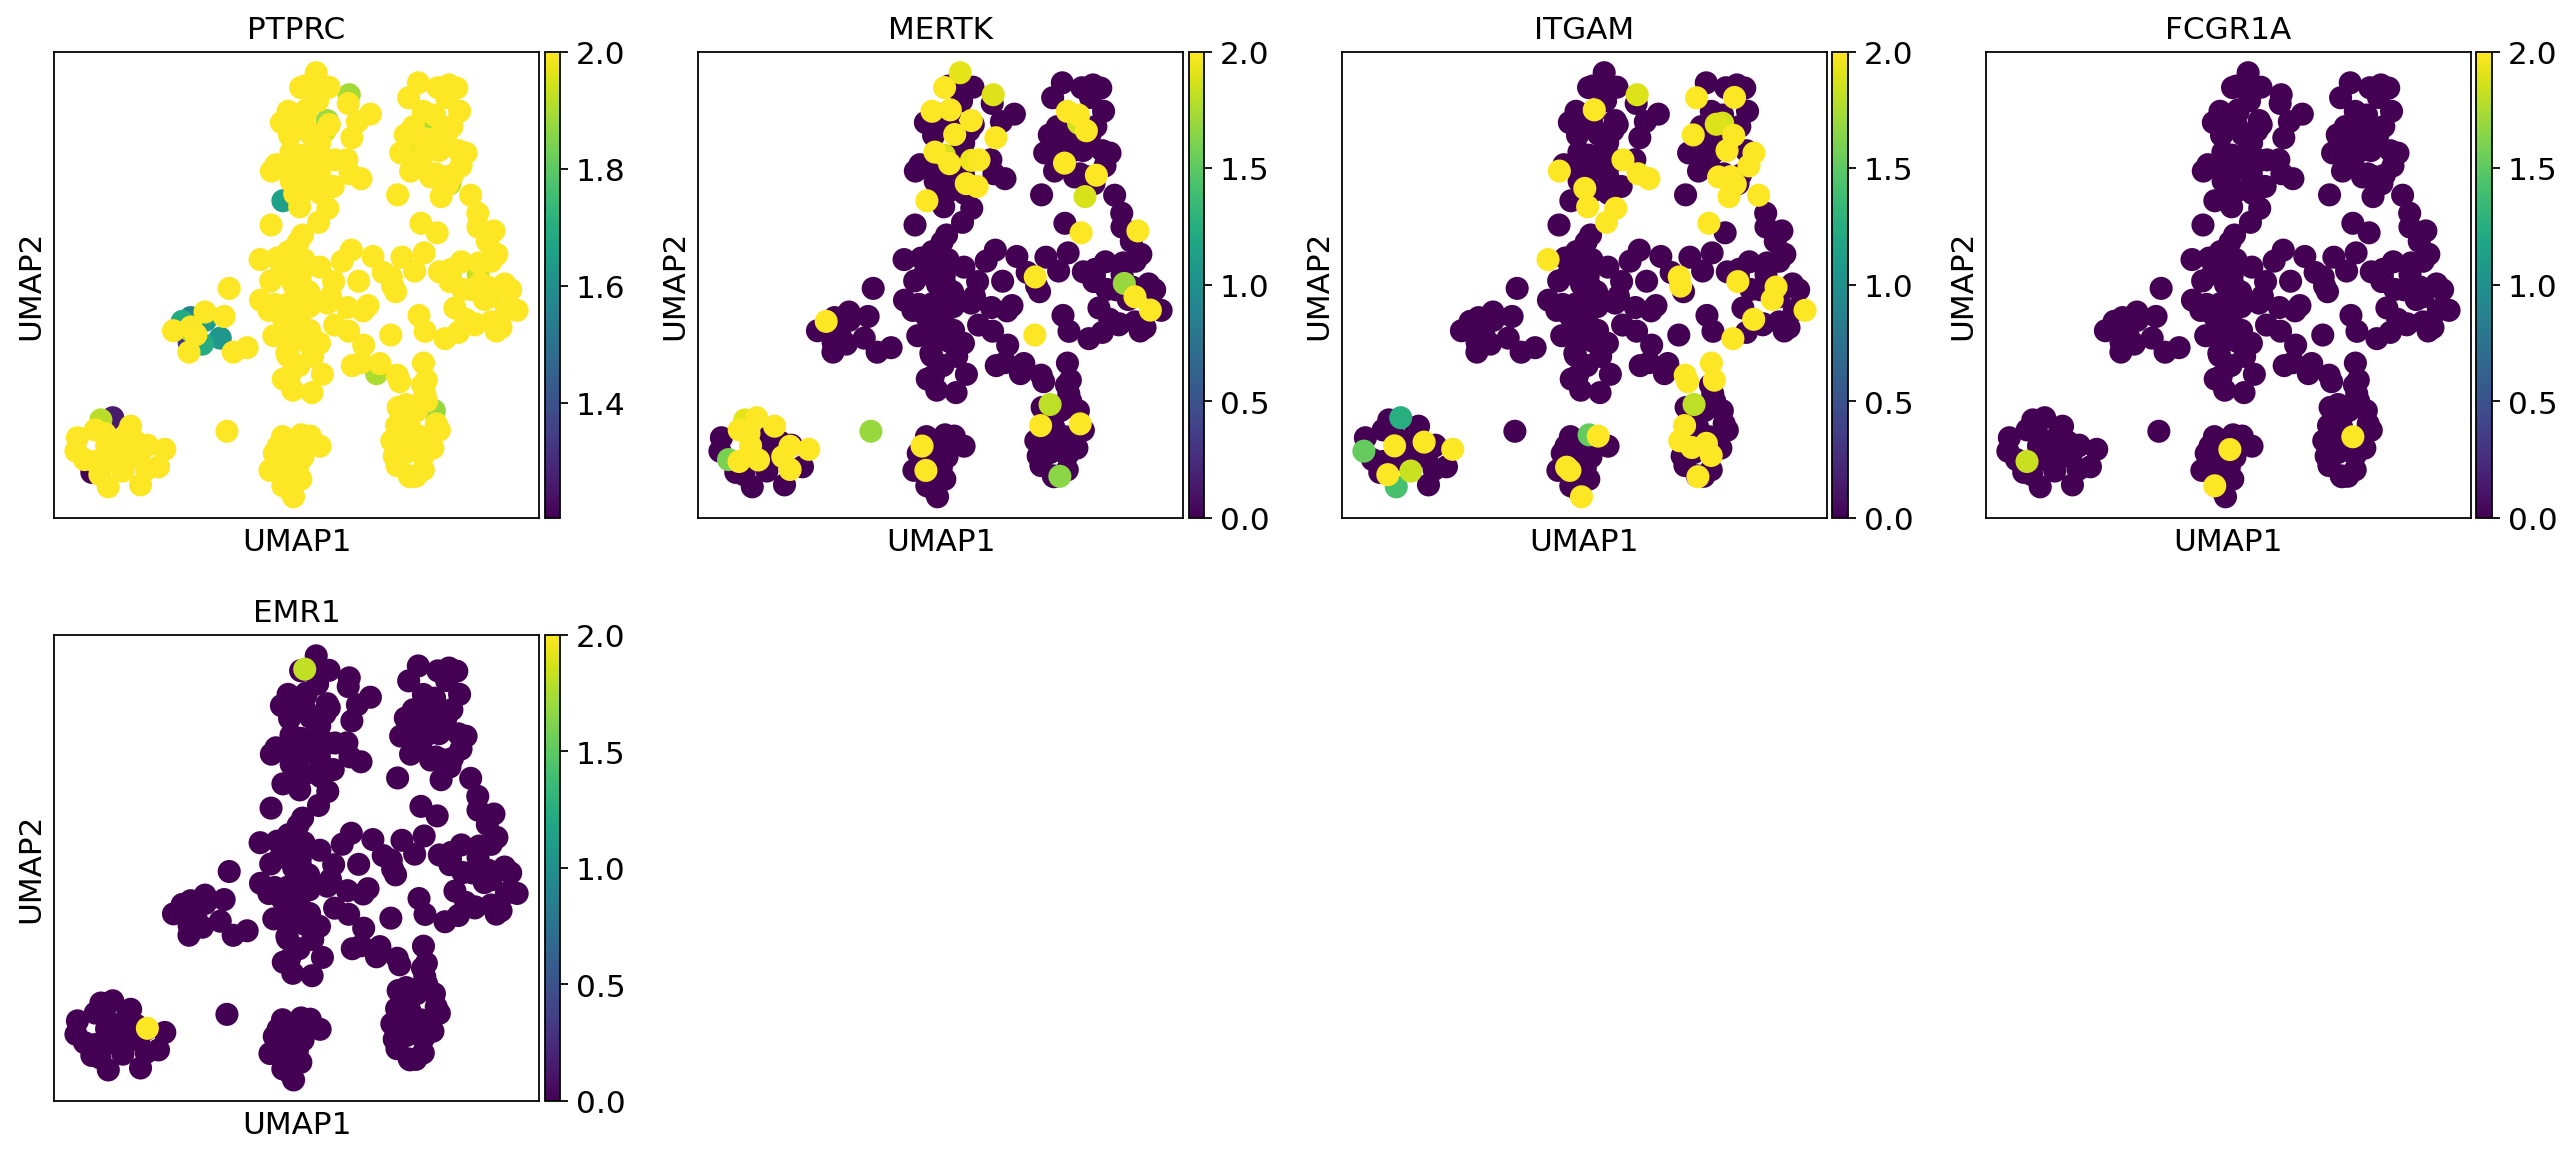

In [187]:
sc.pl.umap(adata_H, color=['PTPRC', 'MERTK',"ITGAM","FCGR1A","EMR1"],vmax = 2) #Plot the UMAP and color by the genes of interest.

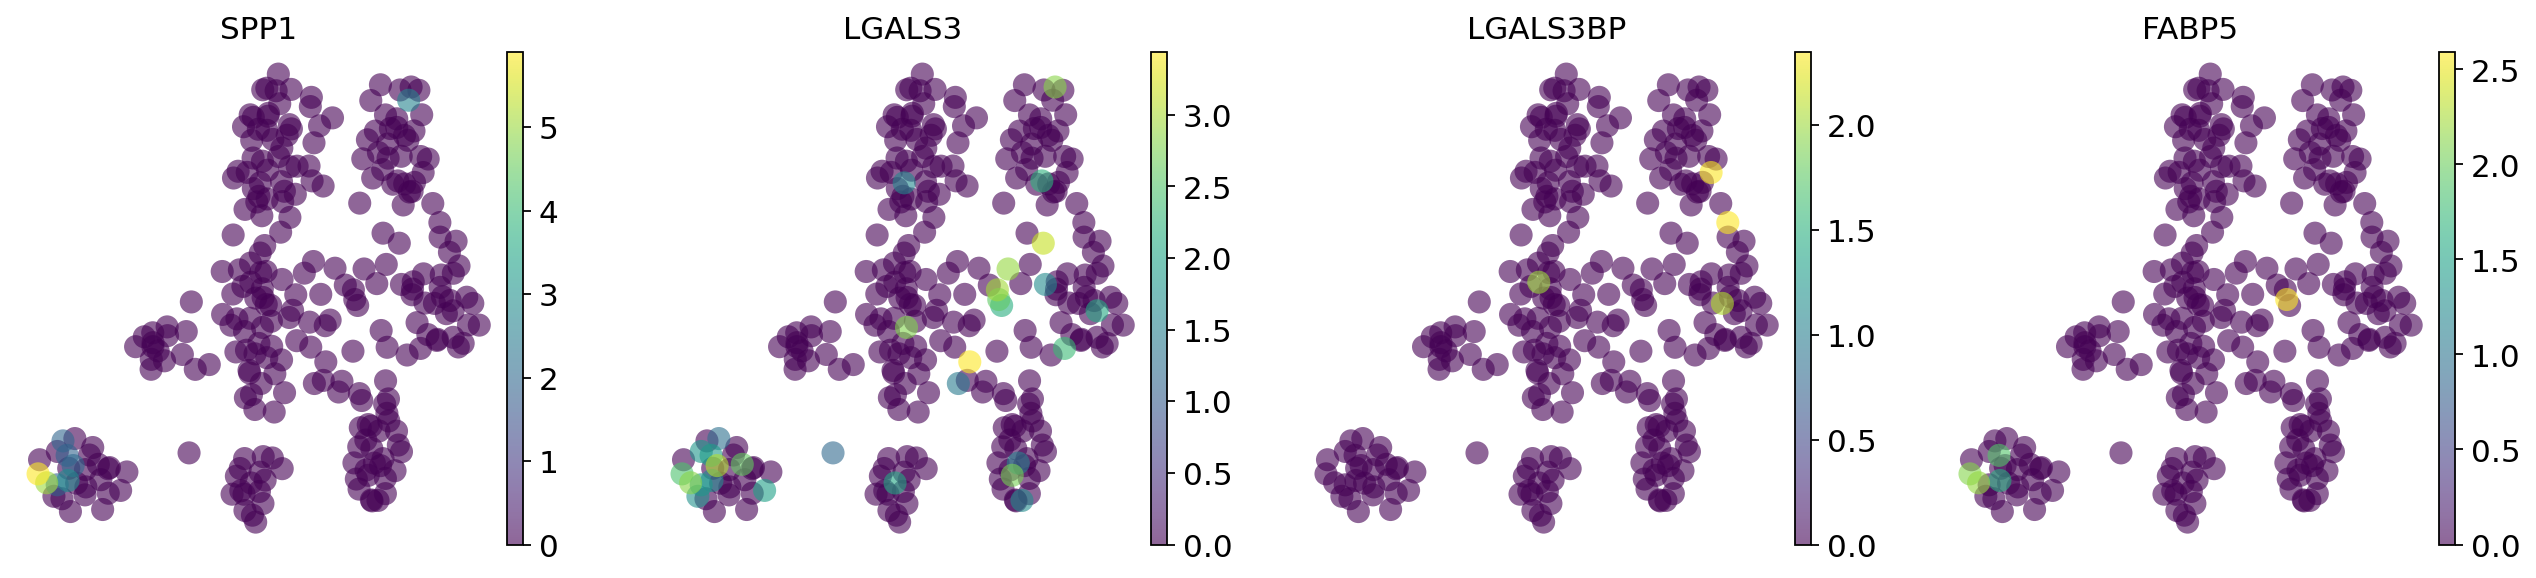

In [188]:
sc.pl.umap(adata_H, color=['SPP1','LGALS3','LGALS3BP', 'FABP5'], alpha=0.6, frameon=False,legend_fontsize = 12,legend_fontweight = 'semibold' )

In [ ]:
adata_H.write("./humanDMD.h5ad")

In [190]:
macro_genes  = ['PTPRC', 'MERTK',"ITGAM","FCGR1A","EMR1"]
sc.tl.score_genes(adata_H, macro_genes,   score_name='macrophage_score')

computing score 'macrophage_score'
    finished: added
    'macrophage_score', score of gene set (adata.obs).
    158 total control genes are used. (0:00:00)


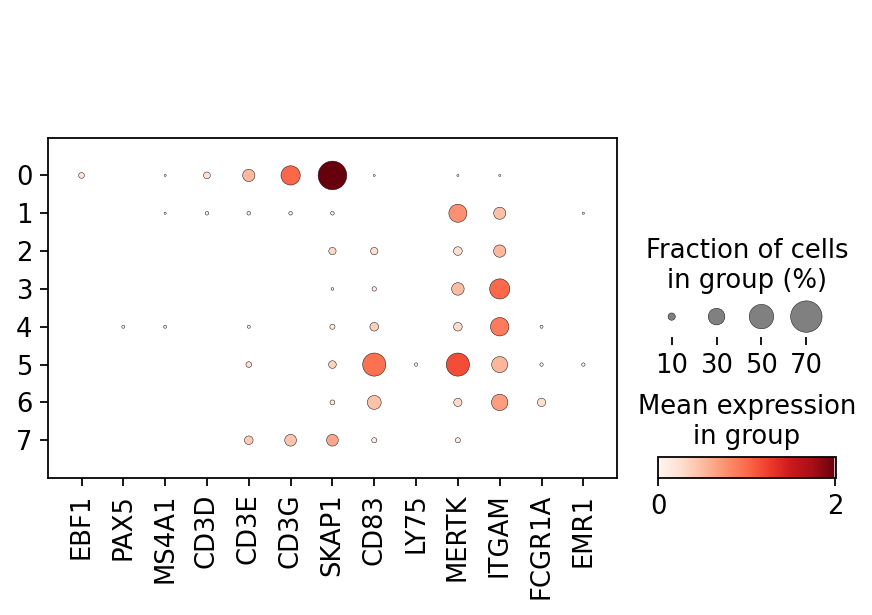

In [193]:
marker_genes_1 = [
    'EBF1','PAX5','MS4A1',# B CELL
    'CD3D', 'CD3E','CD3G','SKAP1',# T CELL
    'CD83', 'LY75',# DC
    'MERTK',"ITGAM","FCGR1A","EMR1", # MP
    ]

sc.pl.dotplot(adata_H , marker_genes_1, groupby='leiden')

In [ ]:
mac_clusters = ['1','2','3','4','5','6']
adata_mac = adata_H[adata_H.obs['leiden'].isin(mac_clusters)].copy()
adata_mac.shape

(207, 4313)

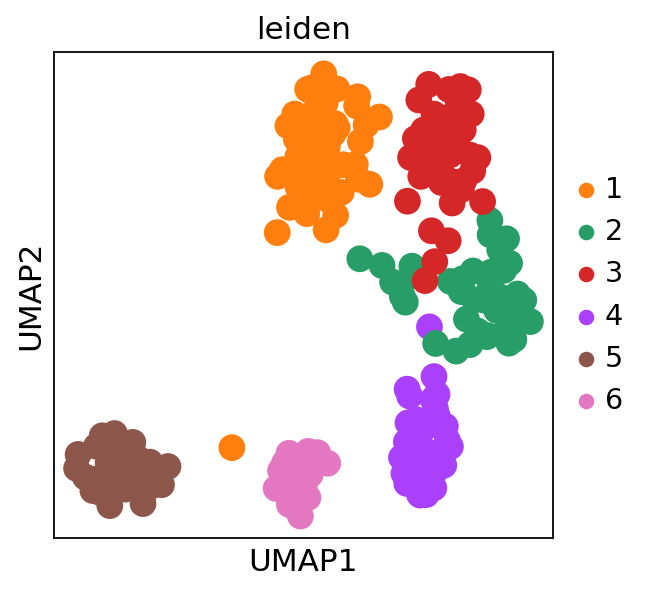

In [195]:
sc.pl.umap(adata_mac, color=["leiden"])

## Pseudo bulk

In [ ]:
# WT Recipient Day1
DMD_sample1 = sc.read_10x_mtx('./humanDMD/fastq/DMD1_count/outs/filtered_feature_bc_matrix/', var_names='gene_symbols',cache=True)
DMD_sample2 = sc.read_10x_mtx('./humanDMD/fastq/DMD2_count/outs/filtered_feature_bc_matrix/', var_names='gene_symbols',cache=True)
DMD_sample3 = sc.read_10x_mtx('./humanDMD/fastq/DMD3_count/outs/filtered_feature_bc_matrix/', var_names='gene_symbols',cache=True)
Healthy_sample1 = sc.read_10x_mtx('./humanDMD/fastq/Healthy1_count/outs/filtered_feature_bc_matrix/', var_names='gene_symbols',cache=True)        
Healthy_sample2 = sc.read_10x_mtx('./humanDMD/fastq/Healthy2_count/outs/filtered_feature_bc_matrix/', var_names='gene_symbols',cache=True)     

... reading from cache file cache/mnt-md0-jiahui-humanDMD-fastq-DMD1_count-outs-filtered_feature_bc_matrix-matrix.h5ad
... reading from cache file cache/mnt-md0-jiahui-humanDMD-fastq-DMD2_count-outs-filtered_feature_bc_matrix-matrix.h5ad
... reading from cache file cache/mnt-md0-jiahui-humanDMD-fastq-DMD3_count-outs-filtered_feature_bc_matrix-matrix.h5ad
... reading from cache file cache/mnt-md0-jiahui-humanDMD-fastq-Healthy1_count-outs-filtered_feature_bc_matrix-matrix.h5ad
... reading from cache file cache/mnt-md0-jiahui-humanDMD-fastq-Healthy2_count-outs-filtered_feature_bc_matrix-matrix.h5ad


In [197]:
for i,a in enumerate([DMD_sample1,DMD_sample2,DMD_sample3,Healthy_sample1,Healthy_sample2]):
    a.obs['dataset']=str(i)

In [198]:
adata_merge = DMD_sample1.concatenate(DMD_sample2,DMD_sample3,Healthy_sample1,Healthy_sample2, batch_key='sample')

/tmp/ipykernel_606254/199008384.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merge = DMD_sample1.concatenate(DMD_sample2,DMD_sample3,Healthy_sample1,Healthy_sample2, batch_key='sample')


In [199]:
adata_merge.obs['is_mac'] = adata_merge.obs_names.isin(adata_mac.obs_names)


In [200]:
adata_merge_mac = adata_merge[adata_merge.obs['is_mac']].copy()
adata_merge_mac

AnnData object with n_obs × n_vars = 207 × 32738
    obs: 'dataset', 'sample', 'is_mac'
    var: 'gene_ids', 'feature_types'

In [ ]:
adata_merge_mac.write("./humanDMD_rawcount.h5ad")